#Лабораторная работа №1

План препроцессинга данных
1. загрузка
2. смотрим типы данных
3. кодирование категориальных признаков
4. просмотр и заполнение пропусков
5. корреляция
6. масштабирование (нормализация и стандартизация) !необязательный этап. Необходимо сделать только в том случае, если у вас разные разрядности значений (например, тысячи в одном признаки и единицы в другом).
7. разделение на обучающую и тестовую выборки
8. балансировка данных (при необходимости) !необязательный этап. Необходимо сделать только в том случае, если есть неравномерность распределения значений между классами.



# Импорт библиотек

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#библиотеки препроцессинга
from sklearn.preprocessing import (LabelEncoder, OneHotEncoder) #кодирование категориальных признаков
from sklearn.preprocessing import (MinMaxScaler, StandardScaler) #масштабирование
from sklearn.model_selection import train_test_split #разделение на обучающую и тестовую выборку

#работа с балансировкой
from imblearn.over_sampling import SMOTE


## Загрузка датасета

In [ ]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d santoshd3/bank-customers
!unzip bank-customers.zip

## Просмотр информации о датасете

In [6]:
df = pd.read_csv('/content/Churn Modeling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
df.describe(include='object')

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


### Проверка на нулевые значения

In [10]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


#Работа с категориальными признаками

###LabelEncoder()

In [11]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

###OneHotEncoder()

In [12]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

### Заполнение пропусков
(среднее/мода)

In [31]:
# числовые
df['Age'] = df['Age'].fillna(df['Age'].mean())

# категориальные
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

## Просмотр количества нулевых значений

In [32]:
df.isna().sum()/df.shape[0]*100

,0
RowNumber,0.0
CreditScore,0.0
Gender,0.0
Age,0.0
Tenure,0.0
Balance,0.0
NumOfProducts,0.0
HasCrCard,0.0
IsActiveMember,0.0
EstimatedSalary,0.0


##Корреляция

In [33]:
df.head()

,RowNumber,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,-1.731878,-0.326221,-1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,1.977165,False,False
1,-1.731531,-0.440036,-1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-0.505775,False,True
2,-1.731185,-1.536794,-1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,1.977165,False,False
3,-1.730838,0.501521,-1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,-0.505775,False,False
4,-1.730492,2.063884,-1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-0.505775,False,True


In [34]:
df.corr()

,RowNumber,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
RowNumber,1.000000,0.005840,0.018196,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571,-0.000044,-0.009905
CreditScore,0.005840,1.000000,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780
Gender,0.018196,-0.002857,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512,-0.024628,0.016889
Age,0.000783,-0.003965,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685
Tenure,-0.006495,0.000842,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868
Balance,-0.009067,0.006268,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892
NumOfProducts,0.007246,0.012238,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039
HasCrCard,0.000599,-0.005458,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480
IsActiveMember,0.012044,0.025651,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732
EstimatedSalary,-0.005988,-0.001384,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482


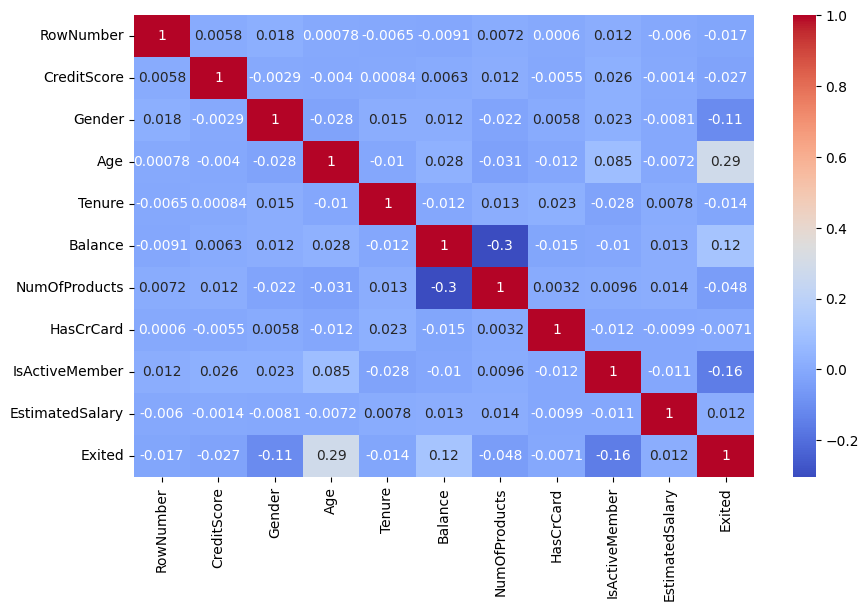

In [36]:
# удаляем лишнее
#df = df.drop(['Surname', 'CustomerId'], axis=1)

# тепловая карта
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

<Axes: >

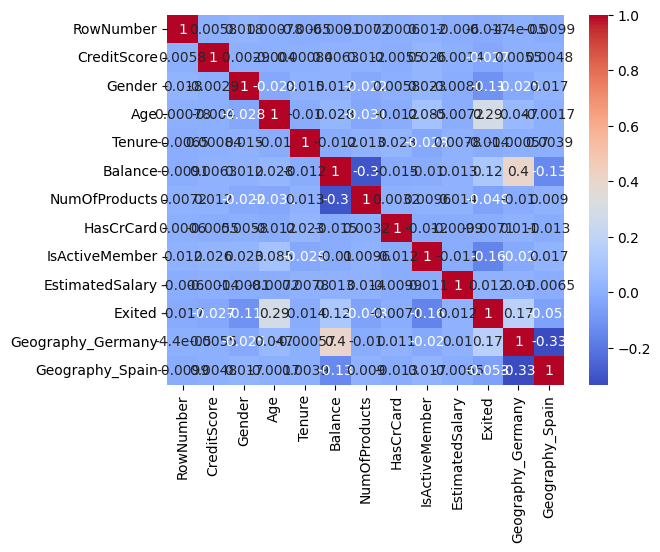

In [37]:
#визуализация
sns.heatmap(df.corr(), cmap = 'coolwarm', annot = True)

### Самые коррелируемые признаки

In [38]:
k = 4
corrmat = df.corr(numeric_only=True)

cols = corrmat.nlargest(k, 'Exited')['Exited']
cols

,Exited
Exited,1.000000
Age,0.285323
Geography_Germany,0.173488
Balance,0.118533


In [39]:
df[cols.index.to_list()]

,Exited,Age,Geography_Germany,Balance
0,1.977165,0.293517,False,-1.225848
1,-0.505775,0.198164,False,0.117350
2,1.977165,0.293517,False,1.333053
3,-0.505775,0.007457,False,-1.225848
4,-0.505775,0.388871,False,0.785728
...,...,...,...,...
9995,-0.505775,0.007457,False,-1.225848
9996,-0.505775,-0.373958,False,-0.306379
9997,1.977165,-0.278604,False,-1.225848
9998,1.977165,0.293517,True,-0.022608


<Axes: >

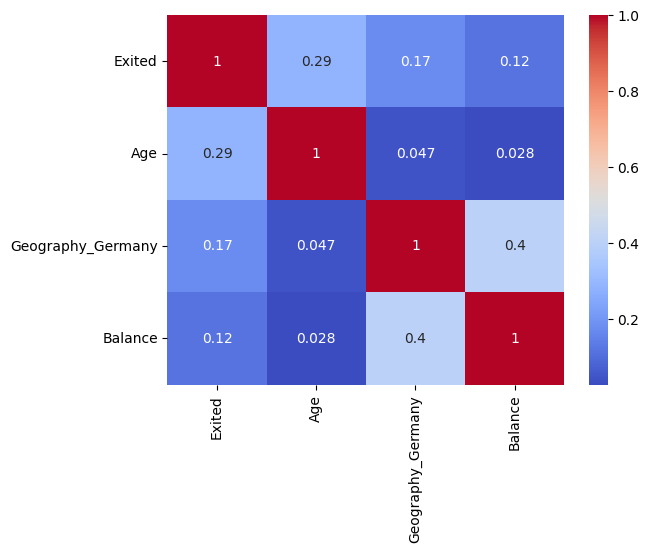

In [40]:
#визуализация
sns.heatmap(df[cols.index.to_list()].corr(), cmap = 'coolwarm', annot = True)

##Масштабирование

In [27]:
df.columns

Index(['RowNumber', 'CreditScore', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Geography_Germany', 'Geography_Spain'],
      dtype='object')

### Масштабируем признаки (от -1 до 1)

In [28]:
scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])